# Code for Chapter 6 @ SSTC-NEU modified by Fu
## Convolutional Neural Networks

In [2]:
import torch # torch will allow us to create tensors.
import torch.nn as nn # torch.nn allows us to create a neural network.
import torch.nn.functional as F # nn.functional give us access to the activation and loss functions.
from torch.optim import Adam # optim contains many optimizers. This time we're using Adam

import lightning as L # lightning has tons of cool tools that make neural networks easier
from torch.utils.data import TensorDataset, DataLoader # these are needed for the training data

import matplotlib.pyplot as plt ## matplotlib allows us to draw the images used for input.

## NOTE: If you get an error running this block of code, it is probably
##       because you installed a new package earlier and forgot to
##       restart your session for python to find the new module(s).
##
##       To restart your session:
##       - In Google Colab, click on the "Runtime" menu and select
##         "Restart Session" from the pulldown menu
##       - In a local jupyter notebook, click on the "Kernel" menu and select
##         "Restart Kernel" from the pulldown menu

In [3]:
## Create a 6x6 matrix of numbers where 0 represents white
## and 1 represents black.
o_image = [[0, 0, 1, 1, 0, 0],
           [0, 1, 0, 0, 1, 0],
           [1, 0, 0, 0, 0, 1],
           [1, 0, 0, 0, 0, 1],
           [0, 1, 0, 0, 1, 0],
           [0, 0, 1, 1, 0, 0]]
o_image # print out the matrix to verify that it is what we expect

[[0, 0, 1, 1, 0, 0],
 [0, 1, 0, 0, 1, 0],
 [1, 0, 0, 0, 0, 1],
 [1, 0, 0, 0, 0, 1],
 [0, 1, 0, 0, 1, 0],
 [0, 0, 1, 1, 0, 0]]

In [4]:
x_image = [[1, 0, 0, 0, 0, 1],
           [0, 1, 0, 0, 1, 0],
           [0, 0, 1, 1, 0, 0],
           [0, 0, 1, 1, 0, 0],
           [0, 1, 0, 0, 1, 0],
           [1, 0, 0, 0, 0, 1]]
x_image

[[1, 0, 0, 0, 0, 1],
 [0, 1, 0, 0, 1, 0],
 [0, 0, 1, 1, 0, 0],
 [0, 0, 1, 1, 0, 0],
 [0, 1, 0, 0, 1, 0],
 [1, 0, 0, 0, 0, 1]]

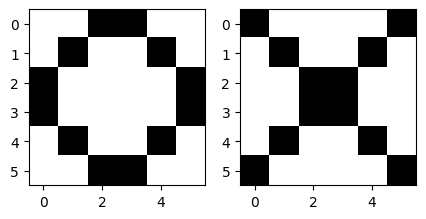

In [5]:
## To draw the o_image and x_image, we first call subplots(), which creates 
## an array, called axarr[], with an entry for each element in a grid
## specified by nrows and ncols.
fig, axarr = plt.subplots(nrows=1, ncols=2, figsize=(5, 5))

## Now we pass o_image and x_image to .imshow() for each element
## in the grid created by plt.subplots()
axarr[0].imshow(o_image, cmap='gray_r') ## Setting cmap='gray_r' gives us reverse grayscale.
axarr[1].imshow(x_image, cmap='gray_r')

In [6]:
## Convert the images into tensors...
input_images = torch.tensor([o_image, x_image]).type(torch.float32)

In [7]:
## Create the labels for the input images
input_labels = torch.tensor([[1.0, 0.0], [0.0, 1.0]]).type(torch.float32)

In [8]:
## Now combine input_images and input_labels into a TensorDataset...
dataset = TensorDataset(input_images, input_labels) 
## ...and use the TensorDataset to create a DataLoader.
dataloader = DataLoader(dataset)

In [9]:
for batch_num, (images, labels) in enumerate(dataloader): 
    print("batch_num:", batch_num)
    print(images)
    print(labels)
    print() ## print a blank line to separate each batch

batch_num: 0
tensor([[[0., 0., 1., 1., 0., 0.],
         [0., 1., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 1.],
         [1., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 1., 0., 0.]]])
tensor([[1., 0.]])

batch_num: 1
tensor([[[1., 0., 0., 0., 0., 1.],
         [0., 1., 0., 0., 1., 0.],
         [0., 0., 1., 1., 0., 0.],
         [0., 0., 1., 1., 0., 0.],
         [0., 1., 0., 0., 1., 0.],
         [1., 0., 0., 0., 0., 1.]]])
tensor([[0., 1.]])



In [10]:
## Now build a simple CNN...
class SimpleCNN(L.LightningModule):
    
    def __init__(self):
        
        super().__init__() ## We call the __init__() for the parent, LightningModule, so that it
                           ## can initialize itself as well.
        
        ## Now we set the seed for the random number generorator.
        ## This ensures that when you create a model from this class, that model
        ## will start off with the exact same random numbers that I started out with when
        ## I created this demo. At least, I hope that is what happens!!! :)
        L.seed_everything(seed=42)
        
        ############################################################################
        ##
        ## Here is where we initialize the Weights and Biases for the CNN
        ##
        ############################################################################
        
        ## The filter is created and applied by nn.Conv2d().
        ## in_channels - The number of color channels that
        ##    the image has. Our black and white image only 
        ##    has one channel. However, color pictures usually have 3.
        ## out_channels - If we had multiple input channels, we could merge
        ##    them down to one output. Or we can increase the number of
        ##    output channels if we want.
        ## kernel_size - The size of the filter (aka kernel). In this case
        ##    we want a 3x3 filter, but you can select all kinds of sizes,
        ##    including sizes that are more rectangular than square.
        self.conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3)
        
        ## nn.MaxPool2d() does the max pooling step.
        ## kernel_size - The size of the filter (aka kernel) that does the
        ##    max pooling. We're using a 2x2 grid for our filter.
        ## stride - How much to move the filter each step. In this case
        ##    we're moving it 2 units. Thus, our 2x2 filter does max pooling
        ##    before moving 2 units over (or down). This means that our 
        ##    max pooling filter never overlaps itself.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        ## Lastly, we create the "normal" neural network that has
        ## 4 inputs, in_features=4, going to a single activation function, out_features=1, 
        ## in a single hidden layer...
        self.input_to_hidden = nn.Linear(in_features=4, out_features=1)
        ## ..and the single hidden layer, in_features=1, goes to
        ## two outputs, out_features=2
        self.hidden_to_output = nn.Linear(in_features=1, out_features=2)
        
        ## We'll use Cross Entropy to calculate the loss between what the 
        ## neural network's predictions and actual, or known, species for
        ## each row in the dataset.
        ## To learn more about Cross Entropy, see: https://youtu.be/6ArSys5qHAU
        ## NOTE: nn.CrossEntropyLoss applies a SoftMax function to the values
        ## we give it, so we don't have to do that oursevles. However,
        ## when we use this neural network (after it has been trained), we'll
        ## have to remember to apply a SoftMax function to the output.
        self.loss = nn.CrossEntropyLoss()

        
    def forward(self, x):
        
        ## First we apply a filter to the input image
        x = self.conv(x)
        
        ## Then we run the output from the filter through a ReLU...
        x = F.relu(x)
        
        ## Then we run the output from the ReLU through a Max Pooling layer...
        x = self.pool(x)
        
        ## Now, at this point we have a square matrix of values.
        ## So, in order to use those values as inputs to
        ## a neural network, we use torch.flatten() to 
        ## turn the matrix into a vector.
        x = torch.flatten(x, 1) # flatten all dimensions except batch 

        ## Now we run the flattened values through a neural network
        ## with a single hidden layer and a single ReLU activation
        ## function in that layer.
        x = self.input_to_hidden(x)
        x = F.relu(x)
        x = self.hidden_to_output(x)
        
        return x

    
    def configure_optimizers(self):
        ## In this example, configuring the optimizer
        ## consists of passing it the weights and biases we want
        ## to optimize, which are all in self.parameters(),
        ## and setting the learning rate with lr=0.001.
        return Adam(self.parameters(), lr=0.001)

    
    def training_step(self, batch, batch_idx):
        ## The first thing we do is split 'batch'
        ## into the input and label values.
        inputs, labels = batch 
        
        ## Then we run the input through the neural network
        outputs = self.forward(inputs)
        
        ## Then we calculate the loss.
        loss = self.loss(outputs, labels)
        
        ## Lastly, we could add the loss to a log file
        ## so that we can graph it later. This would
        ## help us decide if we have done enough training
        ## Ideally, if we do enough training, the loss
        ## should be small and not getting any smaller.
        # self.log("loss", loss) 
        
        return loss

In [11]:
model = SimpleCNN()

In [12]:
trainer = L.Trainer(max_epochs=100)
trainer.fit(model, train_dataloaders=dataloader)

2026-04-13 15:59:07.127153: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 15:59:07.183513: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 15:59:07.186045: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/cuda-12.3/lib64
2026-04-13 15:59:07.186055: I tensorflow/stream_executor/cuda/cudart_stub.cc:29]

Training: |          | 0/? [00:00<?, ?it/s]

In [13]:
for batch_num, (image, label) in enumerate(dataloader):
    
    ## First, run the image through the model to make a prediction
    prediction = model(image)
    
    ## Now make the prediction easy to read and interpret by
    ## running it through torch.softmax() and torch.round()
    predicted_label = torch.round(torch.softmax(prediction, dim=1), ## dim=0 applies softmax to rows, dim=1 applies soft to columns
                                  decimals=2) 
    
    ## Now print out the the predicted label and the original label
    ## so we see how well our CNN performed.
    print("predicted_label:", predicted_label)
    print("original label:", label)
    print("\n")

predicted_label: tensor([[0.5200, 0.4800]], grad_fn=<RoundBackward1>)
original label: tensor([[1., 0.]])


predicted_label: tensor([[0.4200, 0.5800]], grad_fn=<RoundBackward1>)
original label: tensor([[0., 1.]])




In [14]:
path_to_checkpoint = trainer.checkpoint_callback.best_model_path ## By default, "best" = "most recent"

In [15]:
## First, create a new Lightning Trainer
trainer = L.Trainer(max_epochs=700) # Before, max_epochs=100, so, by setting it to 700, we're adding 600 more.

## Then call trainer.fit() using the path to the most recent checkpoint files
## so that we can pick up where we left off.
trainer.fit(model, train_dataloaders=dataloader, ckpt_path=path_to_checkpoint)

/home/chason/anaconda3/envs/jupyter-server/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:566: The dirpath has changed from '/home/chason/Project/My-DL-CODE/My-DL-CODE/lightning_logs/version_4/checkpoints' to '/home/chason/Project/My-DL-CODE/My-DL-CODE/lightning_logs/version_5/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.


Training: |          | 0/? [00:00<?, ?it/s]

In [16]:
for batch_num, (image, label) in enumerate(dataloader):
    
    ## First, run the image through the model to make a prediction
    prediction = model(image)
    
    ## Now make the prediction easy to read and interpret by
    ## running it through torch.softmax() and torch.round()
    predicted_label = torch.round(torch.softmax(prediction, dim=1), ## dim=0 applies softmax to rows, dim=1 applies soft to columns
                                  decimals=2) 
    
    ## Now print out the the predicted label and the original label
    ## so we see how well our CNN performed.
    print("predicted_label:", predicted_label)
    print("original label:", label)
    print("\n")

predicted_label: tensor([[0.7900, 0.2100]], grad_fn=<RoundBackward1>)
original label: tensor([[1., 0.]])


predicted_label: tensor([[0.0100, 0.9900]], grad_fn=<RoundBackward1>)
original label: tensor([[0., 1.]])




In [17]:
shifted_x_image = [[0, 1, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 1],
                   [0, 0, 0, 1, 1, 0],
                   [0, 0, 0, 1, 1, 0],
                   [0, 0, 1, 0, 0, 1],
                   [0, 1, 0, 0, 0, 0]]
shifted_x_image

[[0, 1, 0, 0, 0, 0],
 [0, 0, 1, 0, 0, 1],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 0, 1, 1, 0],
 [0, 0, 1, 0, 0, 1],
 [0, 1, 0, 0, 0, 0]]

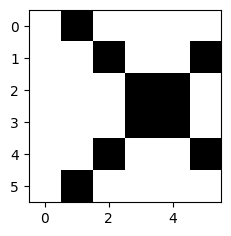

In [18]:
## When we only want to draw one image, we can omit 'nrows' and 'ncols' and 
## a single drawing element, ax, is returned.
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(shifted_x_image, cmap='gray_r') ## Setting cmap='gray_r' gives us reverse grayscale.

In [19]:
## First, let's make a prediction with the new image...
prediction = model(torch.tensor([shifted_x_image]).type(torch.float32))

## Now make the prediction easy to read and interpret by
## running it through torch.softmax() and torch.round()
predicted_label = torch.round(torch.softmax(prediction, dim=1), decimals=2) ## dim=0 applies argmax to rows, dim=1 applies argmax to colum

predicted_label

tensor([[0.1200, 0.8800]], grad_fn=<RoundBackward1>)

In [20]:
shifted_o_image = [[0, 1, 1, 0, 0, 0],
                   [1, 0, 0, 1, 0, 0],
                   [0, 0, 0, 0, 1, 0],
                   [0, 0, 0, 0, 1, 0],
                   [1, 0, 0, 1, 0, 0],
                   [0, 1, 1, 0, 0, 0]]
shifted_o_image

[[0, 1, 1, 0, 0, 0],
 [1, 0, 0, 1, 0, 0],
 [0, 0, 0, 0, 1, 0],
 [0, 0, 0, 0, 1, 0],
 [1, 0, 0, 1, 0, 0],
 [0, 1, 1, 0, 0, 0]]

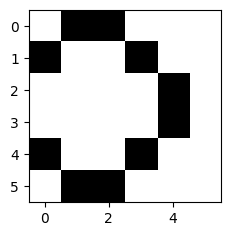

In [21]:
## When we only want to draw one image, we can omit 'nrows' and 'ncols' and 
## a single drawing element, ax, is returned.
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(shifted_o_image, cmap='gray_r') ## Setting cmap='gray_r' gives us reverse grayscale.

In [22]:
## Make a prediction with the new image...
prediction = model(torch.tensor([shifted_o_image]).type(torch.float32))

## Now make the prediction easy to read and interpret by
## running it through torch.softmax() and torch.round()
predicted_label = torch.round(torch.softmax(prediction, dim=1), decimals=2) ## dim=0 applies argmax to rows, dim=1 applies argmax to colum

predicted_label

tensor([[0.4500, 0.5500]], grad_fn=<RoundBackward1>)